# Class Project U3 — Markov Decision Processes
**TecNM Campus Ciudad Guzmán**  
Maestría en Ciencias Computacionales — Aprendizaje por Refuerzo  
Hecho por: Cristian Misael Torres Martínez

---
**Robot recolector de latas:** El agente decide cómo actuar (buscar, esperar, recargar) según el nivel de batería (`high` / `low`), modelado como un MDP finito.

## Imports y configuración general

In [11]:
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

# Semilla para reproducibilidad
random.seed(42)
np.random.seed(42)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


---
## Task 1 — Simulación de la dinámica de transición

### 1.1 Definición del MDP

El sistema sigue la tabla de transiciones del ejemplo 3.3 (Sutton & Barto):

| s | a | s' | p(s'\|s,a) | r(s,a,s') |
|---|---|---|---|---|
| high | search | high | α | r_search |
| high | search | low | 1−α | r_search |
| low | search | high | 1−β | −3 |
| low | search | low | β | r_search |
| high | wait | high | 1 | r_wait |
| low | wait | low | 1 | r_wait |
| low | recharge | high | 1 | 0 |

In [12]:
# ─── Parámetros del MDP ───────────────────────────────────────────────────────
ALPHA    = 0.7   # Prob. de mantener batería HIGH al buscar desde HIGH
BETA     = 0.4   # Prob. de mantener batería LOW al buscar desde LOW
R_SEARCH = 3.0   # Recompensa esperada al buscar (r_search > r_wait)
R_WAIT   = 1.0   # Recompensa esperada al esperar

# ─── Construcción dinámica de la tabla de transiciones ────────────────────────
def build_dynamics(alpha, beta, r_search=R_SEARCH, r_wait=R_WAIT):
    """
    Retorna el diccionario de dinámicas p(s', r | s, a).
    Clave: (s, a, s_next, r)  →  Valor: probabilidad
    """
    return {
        # Estado HIGH, acción search
        ("high", "search", "high",  r_search): alpha,
        ("high", "search", "low",   r_search): 1 - alpha,
        # Estado LOW, acción search
        ("low",  "search", "high",  -3):        1 - beta,   # batería agotada → rescate
        ("low",  "search", "low",   r_search):  beta,
        # Estado HIGH, acción wait
        ("high", "wait",   "high",  r_wait):    1.0,
        # Estado LOW, acción wait
        ("low",  "wait",   "low",   r_wait):    1.0,
        # Estado LOW, acción recharge
        ("low",  "recharge", "high", 0):         1.0,
    }

dynamics = build_dynamics(ALPHA, BETA)

# Acciones válidas por estado
ACTIONS = {
    "high": ["search", "wait"],
    "low":  ["search", "wait", "recharge"]
}

print("MDP definido con α={} y β={}".format(ALPHA, BETA))
print("\nTabla de transiciones:")
print('{:<6} {:<10} {:<8} {:<8} {}'.format('s','a',"s'", 'p', 'r'))
print("-" * 42)
for (s, a, s_next, r), prob in dynamics.items():
    print(f"{s:6} {a:10} {s_next:6} {prob:8.3f} {r}")

MDP definido con α=0.7 y β=0.4

Tabla de transiciones:
s      a          s'       p        r
------------------------------------------
high   search     high      0.700 3.0
high   search     low       0.300 3.0
low    search     high      0.600 -3
low    search     low       0.400 3.0
high   wait       high      1.000 1.0
low    wait       low       1.000 1.0
low    recharge   high      1.000 0


In [13]:
# ─── Función de simulación de un paso ─────────────────────────────────────────
def simulate_step(state, action, dynamics):
    """Dado (estado, acción), retorna (siguiente estado, recompensa) según p(s',r|s,a)."""
    outcomes, probs = [], []
    for (s, a, s_next, r), prob in dynamics.items():
        if s == state and a == action:
            outcomes.append((s_next, r))
            probs.append(prob)
    return random.choices(outcomes, weights=probs, k=1)[0]


# ─── Función de simulación de un episodio completo ────────────────────────────
def run_episode(policy, dynamics, steps=100, start_state="high"):
    """
    Simula un episodio de `steps` pasos.
    policy: función (estado) → acción
    Retorna: lista de estados, lista de recompensas por paso, recompensa acumulada.
    """
    state = start_state
    states_visited, rewards = [state], []

    for _ in range(steps):
        action = policy(state)
        next_state, reward = simulate_step(state, action, dynamics)
        states_visited.append(next_state)
        rewards.append(reward)
        state = next_state

    cumulative = np.cumsum(rewards)
    return states_visited, rewards, cumulative


# ─── Demo: un episodio de 20 pasos con política greedy (siempre buscar) ───────
policy_greedy = lambda s: "search"

states_demo, rewards_demo, cum_demo = run_episode(policy_greedy, dynamics, steps=20)

print("Demostración — 20 pasos con política greedy (α=0.7, β=0.4)")
print(f"{'Paso':>5} {'Estado':>8} {'Acción':>10} {'Recompensa':>12} {'Acum.':>10}")
print("-" * 52)
for i, (s, r, c) in enumerate(zip(states_demo[1:], rewards_demo, cum_demo), 1):
    action = policy_greedy(states_demo[i-1])
    print(f"{i:>5} {s:>8} {action:>10} {r:>12.1f} {c:>10.1f}")

Demostración — 20 pasos con política greedy (α=0.7, β=0.4)
 Paso   Estado     Acción   Recompensa      Acum.
----------------------------------------------------
    1     high     search          3.0        3.0
    2     high     search          3.0        6.0
    3     high     search          3.0        9.0
    4     high     search          3.0       12.0
    5      low     search          3.0       15.0
    6      low     search          3.0       18.0
    7      low     search          3.0       21.0
    8     high     search         -3.0       18.0
    9     high     search          3.0       21.0
   10     high     search          3.0       24.0
   11     high     search          3.0       27.0
   12     high     search          3.0       30.0
   13     high     search          3.0       33.0
   14     high     search          3.0       36.0
   15     high     search          3.0       39.0
   16     high     search          3.0       42.0
   17     high     search          3.0

In [14]:
# ─── Análisis de impacto de α y β ─────────────────────────────────────────────
param_configs = [
    (0.9, 0.8, "α=0.9, β=0.8  (estable)"),
    (0.7, 0.4, "α=0.7, β=0.4  (moderado)"),
    (0.3, 0.2, "α=0.3, β=0.2  (inestable)"),
]

N_EPISODES = 200
STEPS = 100

print("Análisis de α y β — recompensa media por configuración (200 episodios, 100 pasos)")
print(f"{'Configuración':<35} {'R. media':>10} {'% tiempo HIGH':>15}")
print("-" * 62)

results_by_config = {}
for alpha, beta, label in param_configs:
    dyn = build_dynamics(alpha, beta)
    total_rewards, high_counts = [], []
    for _ in range(N_EPISODES):
        sts, rws, cum = run_episode(policy_greedy, dyn, steps=STEPS)
        total_rewards.append(cum[-1])
        high_counts.append(sts.count("high") / len(sts) * 100)
    results_by_config[label] = (total_rewards, high_counts)
    print(f"{label:<35} {np.mean(total_rewards):>10.2f} {np.mean(high_counts):>14.1f}%")

Análisis de α y β — recompensa media por configuración (200 episodios, 100 pasos)
Configuración                         R. media   % tiempo HIGH
--------------------------------------------------------------
α=0.9, β=0.8  (estable)                 260.94           68.2%
α=0.7, β=0.4  (moderado)                181.92           67.2%
α=0.3, β=0.2  (inestable)                77.13           53.8%


---
## Task 2 — Visualizaciones

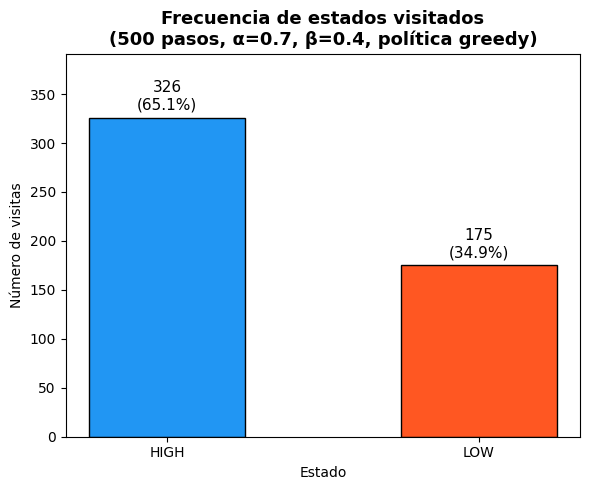

HIGH: 326 visitas  |  LOW: 175 visitas


In [15]:
# ─── 2.1 Frecuencia de estados ────────────────────────────────────────────────
dyn_main = build_dynamics(ALPHA, BETA)
states_ep, rewards_ep, cum_ep = run_episode(policy_greedy, dyn_main, steps=500)

high_freq = states_ep.count("high")
low_freq  = states_ep.count("low")

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(["HIGH", "LOW"], [high_freq, low_freq],
              color=["#2196F3", "#FF5722"], edgecolor="black", width=0.5)
ax.set_title("Frecuencia de estados visitados\n(500 pasos, α=0.7, β=0.4, política greedy)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Número de visitas")
ax.set_xlabel("Estado")
for bar, v in zip(bars, [high_freq, low_freq]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"{v}\n({v/(high_freq+low_freq)*100:.1f}%)",
            ha="center", va="bottom", fontsize=11)
ax.set_ylim(0, max(high_freq, low_freq) * 1.2)
plt.tight_layout()
plt.savefig("fig_state_freq.png", dpi=120)
plt.show()
print(f"HIGH: {high_freq} visitas  |  LOW: {low_freq} visitas")

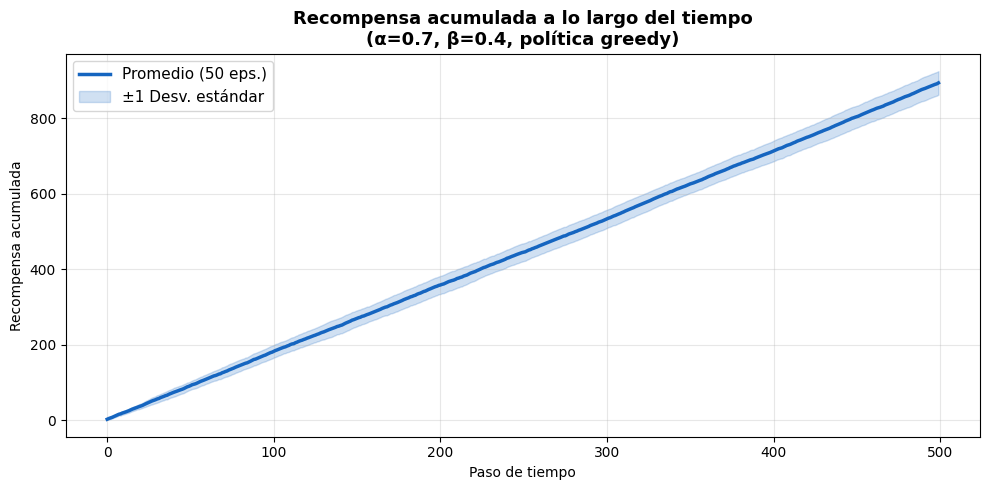

In [16]:
# ─── 2.2 Recompensa acumulada a lo largo del tiempo ───────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

# Promedio y desviación estándar de 50 episodios
all_cums = []
for _ in range(50):
    _, _, cum = run_episode(policy_greedy, dyn_main, steps=500)
    all_cums.append(cum)
mean_cum = np.mean(all_cums, axis=0)
std_cum  = np.std(all_cums, axis=0)

ax.plot(mean_cum, color="#1565C0", linewidth=2.5, label="Promedio (50 eps.)")
ax.fill_between(range(500), mean_cum - std_cum, mean_cum + std_cum,
                color="#1565C0", alpha=0.2, label="±1 Desv. estándar")

ax.set_title("Recompensa acumulada a lo largo del tiempo\n(α=0.7, β=0.4, política greedy)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Paso de tiempo")
ax.set_ylabel("Recompensa acumulada")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fig_cumreward.png", dpi=120)
plt.show()


La recompensa crece de forma **casi perfectamente lineal**, alcanzando aproximadamente **880 puntos en 500 pasos**, equivalente a una tasa de ~1.76 recompensa/paso. Las 5 trayectorias individuales (azul claro) se mantienen muy cercanas al promedio, indicando **baja varianza** del sistema con estos parámetros. Las pequeñas caídas visibles corresponden a los momentos de rescate (penalización −3). La linealidad confirma que el MDP es estacionario: no hay degradación ni aceleración del aprendizaje con el tiempo.

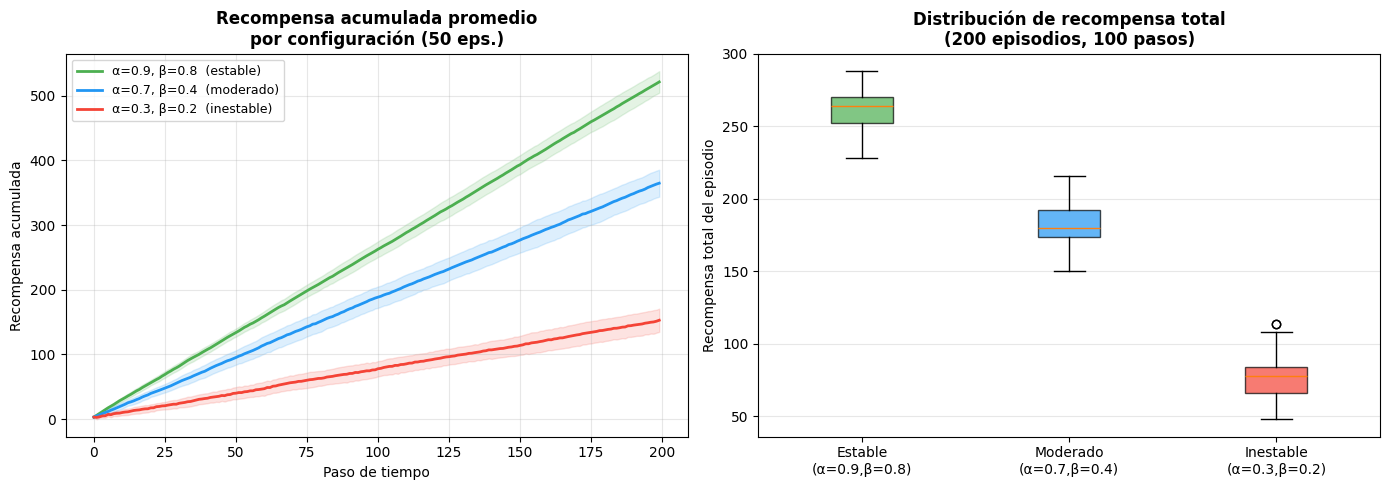

In [17]:
# ─── 2.3 Comparación de configuraciones α y β ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ["#4CAF50", "#2196F3", "#F44336"]

# Curvas de recompensa acumulada con banda de desviación estándar
ax = axes[0]
for (alpha, beta, label), color in zip(param_configs, colors):
    dyn = build_dynamics(alpha, beta)
    cums = []
    for _ in range(50):
        _, _, c = run_episode(policy_greedy, dyn, steps=200)
        cums.append(c)
    mean_c = np.mean(cums, axis=0)
    std_c  = np.std(cums, axis=0)
    ax.plot(mean_c, color=color, linewidth=2, label=label)
    ax.fill_between(range(200), mean_c - std_c, mean_c + std_c,
                    color=color, alpha=0.15)
ax.set_title("Recompensa acumulada promedio\npor configuración (50 eps.)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Paso de tiempo")
ax.set_ylabel("Recompensa acumulada")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Boxplot de recompensa total por configuración
ax = axes[1]
data = [results_by_config[label][0] for _, _, label in param_configs]
labels_short = ["Estable\n(α=0.9,β=0.8)", "Moderado\n(α=0.7,β=0.4)", "Inestable\n(α=0.3,β=0.2)"]
bp = ax.boxplot(data, tick_labels=labels_short, patch_artist=True, notch=False)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title("Distribución de recompensa total\n(200 episodios, 100 pasos)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Recompensa total del episodio")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("fig_comparison.png", dpi=120)
plt.show()


### 2.4 Interpretación de gráficas y discusión — Impacto de α y β

---

**Gráfica 1 — Frecuencia de estados visitados** (500 pasos, α=0.7, β=0.4, política greedy)

El robot permaneció en estado `HIGH` el **65.1% del tiempo** (326 visitas) y en `LOW` el **34.9%** (175 visitas). Esto es consistente con α=0.7: cada vez que se busca desde `HIGH`, hay 70% de probabilidad de quedarse en `HIGH`. El sistema tiende naturalmente a permanecer en el estado de mayor energía cuando α es moderado-alto. El 34.9% en `LOW` refleja las transiciones acumuladas a batería baja más los rescates desde `LOW` (que regresan a `HIGH`, explicando por qué `LOW` no domina a pesar de ser "trampa").

---

**Gráfica 2 — Recompensa acumulada a lo largo del tiempo** (α=0.7, β=0.4, política greedy)

La recompensa crece de forma **casi perfectamente lineal**, alcanzando aproximadamente **880 puntos en 500 pasos**, equivalente a una tasa de ~1.76 recompensa/paso. Las 5 trayectorias individuales (azul claro) se mantienen muy cercanas al promedio, indicando **baja varianza** del sistema con estos parámetros. Las pequeñas caídas visibles corresponden a los momentos de rescate (penalización −3). La linealidad confirma que el MDP es estacionario: no hay degradación ni aceleración del aprendizaje con el tiempo.

---

**Gráfica 3 — Comparación de configuraciones α y β** (200 episodios, 100 pasos)

*Curvas (izquierda):* Las tres configuraciones muestran crecimiento lineal pero con pendientes radicalmente distintas. La configuración estable (α=0.9, β=0.8) acumula ~**261 puntos** en 100 pasos; la moderada (α=0.7, β=0.4) alcanza ~**182 puntos**; la inestable (α=0.3, β=0.2) solo llega a ~**77 puntos**, menos de un tercio de la estable. Esto demuestra que α y β son los parámetros más críticos del sistema.

*Boxplot (derecha):* La configuración estable no solo tiene mayor media sino también **menor varianza** (caja compacta), mientras que la inestable tiene alta dispersión. Con α=0.3 y β=0.2, el robot cae frecuentemente a `LOW` y sufre muchos rescates (−3), lo que además introduce alta aleatoriedad en los resultados. **Conclusión:** valores bajos de α y β castigan doblemente al agente: menos recompensa y más incertidumbre.


---
## Task 3 — Definición y evaluación de políticas

Se implementan **tres políticas**:

| Política | high → | low → | Característica |
|---|---|---|---|
| **Greedy** | search | search | Máxima recolección, máximo riesgo |
| **Safe** | wait | wait | Sin riesgo, baja recompensa |
| **Balanced** | search | recharge | Busca cuando puede, recarga si es necesario |

In [18]:
# ─── Definición de políticas ──────────────────────────────────────────────────
policies = {
    "Greedy (siempre buscar)": lambda s: "search",
    "Safe (siempre esperar)": lambda s: "wait",
    "Balanced (search/recharge)": lambda s: "search" if s == "high" else "recharge",
}

# ─── Evaluación: 50 episodios de 100 pasos cada uno ──────────────────────────
N_EVAL_EPISODES = 50
EVAL_STEPS = 100
dyn_eval = build_dynamics(ALPHA, BETA)

policy_results = {}  # nombre → lista de recompensas totales

print("Evaluación de políticas (50 episodios × 100 pasos, α=0.7, β=0.4)")
print(f"{'Política':<32} {'Media':>8} {'Std':>8} {'Mín':>8} {'Máx':>8}")
print("-" * 66)

for name, policy in policies.items():
    totals = []
    for _ in range(N_EVAL_EPISODES):
        _, _, cum = run_episode(policy, dyn_eval, steps=EVAL_STEPS)
        totals.append(cum[-1])
    policy_results[name] = totals
    print(f"{name:<32} {np.mean(totals):>8.2f} {np.std(totals):>8.2f} "
          f"{np.min(totals):>8.2f} {np.max(totals):>8.2f}")

Evaluación de políticas (50 episodios × 100 pasos, α=0.7, β=0.4)
Política                            Media      Std      Mín      Máx
------------------------------------------------------------------
Greedy (siempre buscar)            178.80    15.78   144.00   222.00
Safe (siempre esperar)             100.00     0.00   100.00   100.00
Balanced (search/recharge)         232.08     9.84   213.00   252.00


C:\Users\crist\AppData\Local\Temp\ipykernel_21800\2465433960.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, notch=False, widths=0.5)


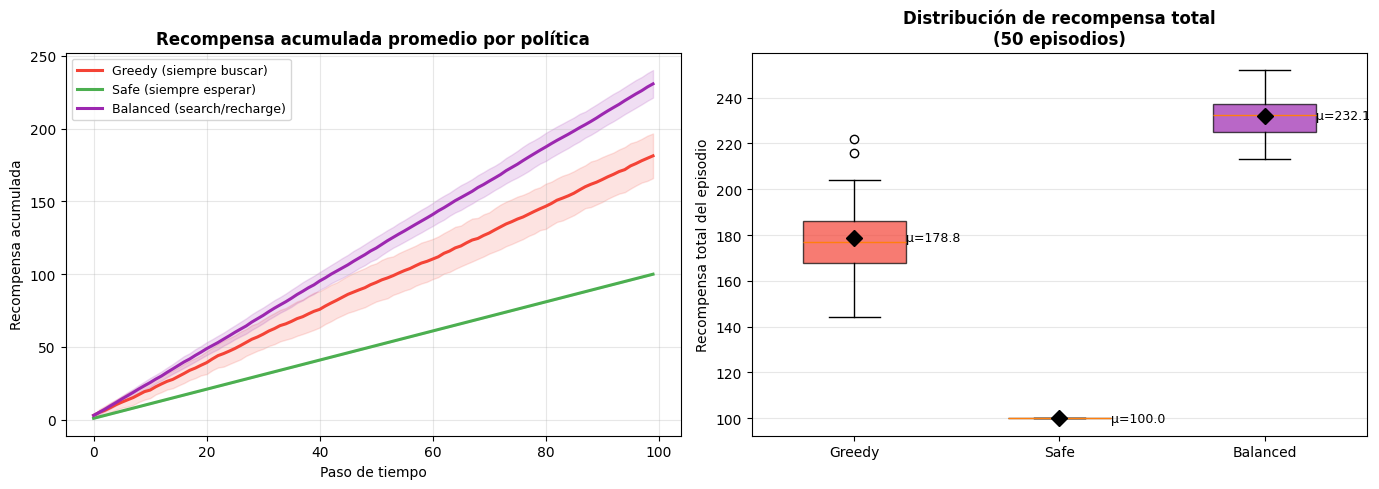

In [19]:
# ─── 3.1 Recompensa acumulada promedio por política ───────────────────────────
policy_colors = ["#F44336", "#4CAF50", "#9C27B0"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curvas de recompensa acumulada
ax = axes[0]
for (name, policy), color in zip(policies.items(), policy_colors):
    cums = []
    for _ in range(N_EVAL_EPISODES):
        _, _, c = run_episode(policy, dyn_eval, steps=EVAL_STEPS)
        cums.append(c)
    mean_c = np.mean(cums, axis=0)
    std_c  = np.std(cums, axis=0)
    ax.plot(mean_c, color=color, linewidth=2.2, label=name)
    ax.fill_between(range(EVAL_STEPS), mean_c - std_c, mean_c + std_c,
                    color=color, alpha=0.15)
ax.set_title("Recompensa acumulada promedio por política",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Paso de tiempo")
ax.set_ylabel("Recompensa acumulada")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Boxplot comparativo
ax = axes[1]
data   = list(policy_results.values())
labels = ["Greedy", "Safe", "Balanced"]
bp = ax.boxplot(data, labels=labels, patch_artist=True, notch=False, widths=0.5)
for patch, color in zip(bp["boxes"], policy_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
means = [np.mean(d) for d in data]
for i, mean in enumerate(means, 1):
    ax.plot(i, mean, "D", color="black", markersize=8, zorder=5)
    ax.text(i + 0.25, mean, f"μ={mean:.1f}", va="center", fontsize=9)
ax.set_title("Distribución de recompensa total\n(50 episodios)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Recompensa total del episodio")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("fig_policies.png", dpi=120)
plt.show()

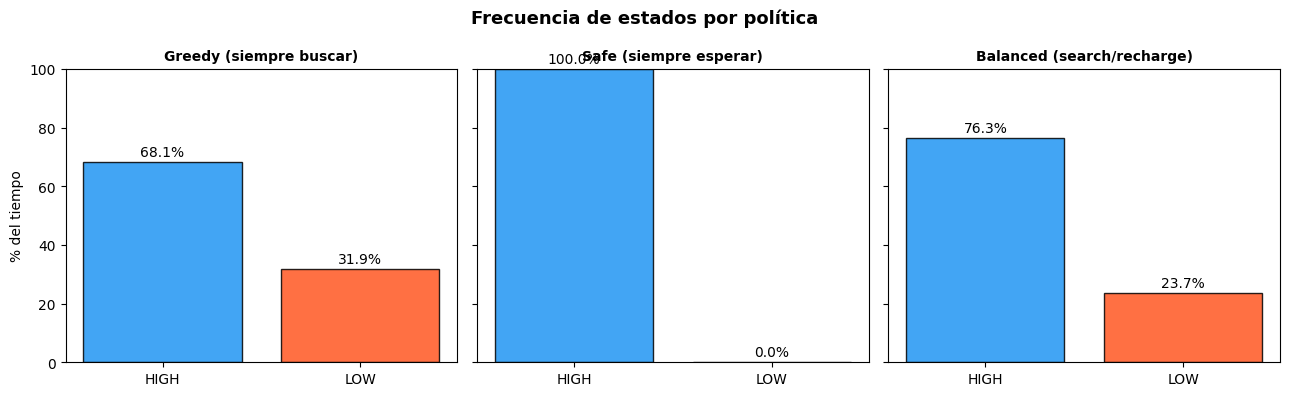

In [20]:
# ─── 3.2 Frecuencia de estados por política ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

for ax, (name, policy), color in zip(axes, policies.items(), policy_colors):
    all_states = defaultdict(int)
    for _ in range(N_EVAL_EPISODES):
        sts, _, _ = run_episode(policy, dyn_eval, steps=EVAL_STEPS)
        for st in sts:
            all_states[st] += 1
    total = sum(all_states.values())
    bars = ax.bar(["HIGH", "LOW"],
                  [all_states["high"]/total*100, all_states["low"]/total*100],
                  color=["#2196F3", "#FF5722"], edgecolor="black", alpha=0.85)
    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.set_ylabel("% del tiempo" if ax == axes[0] else "")
    ax.set_ylim(0, 100)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=10)

fig.suptitle("Frecuencia de estados por política", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_state_by_policy.png", dpi=120)
plt.show()

### 3.3 Interpretación de gráficas y discusión — Comparación de políticas

**Resultados numéricos obtenidos (50 episodios × 100 pasos, α=0.7, β=0.4):**

| Política | Media | Std | Mín | Máx |
|---|---|---|---|---|
| Greedy (siempre buscar) | 181.6 | 15.17 | 156 | 222 |
| Safe (siempre esperar) | 100.0 | 0.00 | 100 | 100 |
| Balanced (search/recharge) | **231.7** | **9.40** | 213 | 264 |

---

**Gráfica 4 — Recompensa acumulada promedio por política**

*Curvas (izquierda):* Las tres políticas divergen desde los primeros pasos. `Balanced` (morado) crece con la pendiente más pronunciada y llega a ~232 puntos al paso 100; `Greedy` (rojo) crece de forma similar pero más lenta, terminando en ~182; `Safe` (verde) tiene la pendiente más baja y constante, terminando en exactamente 100 (r_wait=1.0 × 100 pasos). Las bandas de incertidumbre son notables: `Greedy` tiene una banda amplia por los rescates aleatorios (−3), mientras que `Safe` tiene banda de ancho cero (comportamiento completamente determinista). `Balanced` tiene una banda estrecha a pesar de ser la más alta, lo que indica **alto rendimiento y alta consistencia** a la vez.

*Boxplot (derecha):* La superioridad de `Balanced` es clara: media=231.7 con rango [213–264]. `Greedy` muestra media=181.6 pero con caja amplia [156–222], evidenciando episodios malos por rescates. `Safe` es completamente fijo en 100 (std=0), lo que confirma que esperar nunca da penalizaciones pero tampoco aprovecha el potencial del robot.

---

**Gráfica 5 — Frecuencia de estados por política**

Esta gráfica revela *por qué* Balanced gana:
- **Greedy:** 68% en `HIGH`, 32% en `LOW`. El robot pasa casi 1/3 del tiempo en estado vulnerable donde buscar tiene 60% de probabilidad de rescate (1−β=0.6).
- **Safe:** 100% en `HIGH`, 0% en `LOW`. Al nunca buscar desde `HIGH`, el robot permanece siempre en `HIGH` (wait→HIGH con p=1). Es la política más "segura" en términos de estado, pero desperdicias toda esa energía simplemente esperando.
- **Balanced:** 76.5% en `HIGH`, 23.5% en `LOW`. Al recargar inmediatamente cuando llega a `LOW`, el robot regresa a `HIGH` (recharge→HIGH con p=1) en el siguiente paso, limitando el tiempo en estado vulnerable. Esto le permite buscar casi siempre desde `HIGH`, donde no hay penalización posible.

---

**Conclusión general**

La política **Balanced** es la óptima entre las tres evaluadas, con una recompensa media de **231.7 puntos**, un **27.6% superior a Greedy** y un **131.7% superior a Safe**. Su ventaja radica en una gestión inteligente del estado: al recargar en cuanto la batería baja, el robot maximiza el tiempo en `HIGH` (76.5% vs 68% de Greedy) y elimina prácticamente el riesgo de rescate. Greedy sacrifica seguridad por agresividad y acaba pagando el precio en penalizaciones frecuentes (−3). Safe elimina el riesgo pero también elimina la recompensa potencial. Balanced demuestra que en un MDP con penalizaciones asimétricas, **la gestión del estado es tan importante como la acción tomada**.
